In [29]:
import pandas as pd
df = pd.read_csv("Monthly_Crime_Activity.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Convert date column
df['reporteddate'] = pd.to_datetime(df['reporteddate'], errors='coerce')

# Drop missing important values
df = df.dropna(subset=['reporteddate', 'neighborhood'])

# Create new columns
df['year'] = df['reporteddate'].dt.year
df['month'] = df['reporteddate'].dt.month

# Preview cleaned data
df.head()

/scratch/slurm-36091/ipykernel_73133/809383557.py:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Monthly_Crime_Activity.csv")


,report_number,reporteddate,reportedtime,hour,dayofweek,reportedmonth,nibrs_coded_offense,nibrs_offense_code,nibrs_offense_category,nibrs_offense_type,...,nibrs_offense_grouping,violation,xcoord,ycoord,zone,tract,neighborhood,block_address,year,month
0,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,13A AGGRAVATED ASSAULT,13A,Assault Offenses,Aggravated Assault,...,A,18 2718 A1 Strangulation Basic - Applying,-80.0268,40.3964,Zone 6,1919.0,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA",2024,1
1,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,13C INTIMIDATION,13C,Assault Offenses,Intimidation,...,A,18 2706 A1 Terroristic Threats-General,-80.0268,40.3964,Zone 6,1919.0,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA",2024,1
2,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,90Z ALL OTHER OFFENSES,90Z,All other Offenses,All other Offenses,...,B,75 3733 A Fleeing or Attempting To Elude Polic...,-80.0268,40.3964,Zone 6,1919.0,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA",2024,1
3,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,23H ALL OTHER LARCENY,23H,Larceny/Theft Offenses,All Other Larceny,...,A,18 3921 A Theft by Unlawful Taking-Movable – L...,-80.0268,40.3964,Zone 6,1919.0,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA",2024,1
4,PGHP24000017,2024-01-01,00:21,0,Monday,Jan,9999 Vehicle Offense (Not NIBRS Reportable),999,Not NIBRS Reportable,Not NIBRS Reportable,...,B,LO 6 101 Discharge of Firearms Prohibited,-80.0243,40.4582,Zone 1,2107.0,Manchester,"1200 Block of COLUMBUS AVE Pittsburgh, PA",2024,1


In [28]:
import pandas as pd

# Show all rows
pd.set_option('display.max_rows', None)

# Load dataset
df = pd.read_csv("Monthly_Crime_Activity.csv", low_memory=False)
df.columns = df.columns.str.strip().str.lower()
crime_counts_df = df['neighborhood'].value_counts().reset_index()
crime_counts_df.columns = ['neighborhood', 'crime_count']

# Sort most to least
crime_counts_df = crime_counts_df.sort_values(by='crime_count', ascending=False)

# Print all
print(crime_counts_df.to_string(index=False))

             neighborhood  crime_count
Central Business District         9132
         South Side Flats         5681
                  Carrick         2814
             East Liberty         2437
                Shadyside         2390
           East Allegheny         2295
                Knoxville         1773
               Bloomfield         1764
         Mount Washington         1743
      Squirrel Hill South         1609
                Brookline         1608
                Allentown         1530
           Homewood South         1513
           Homewood North         1341
              North Shore         1289
       Marshall-Shadeland         1286
                Hazelwood         1284
         Crawford-Roberts         1281
                    Bluff         1230
                 Sheraden         1230
              Perry South         1114
               East Hills         1072
              Middle Hill         1057
         Brighton Heights         1043
          Central Oakland

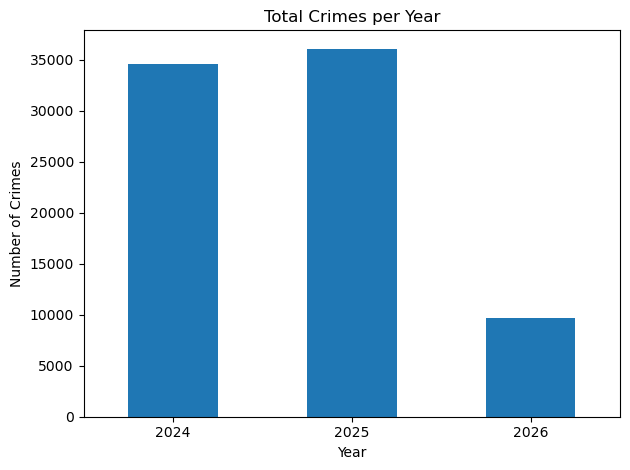

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert date column
df['reporteddate'] = pd.to_datetime(df['reporteddate'], errors='coerce')

# Create year column
df['year'] = df['reporteddate'].dt.year

# Group by year
crimes_per_year = df.groupby('year').size()

# Plot
plt.figure()
crimes_per_year.plot(kind='bar')

plt.title('Total Crimes per Year')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

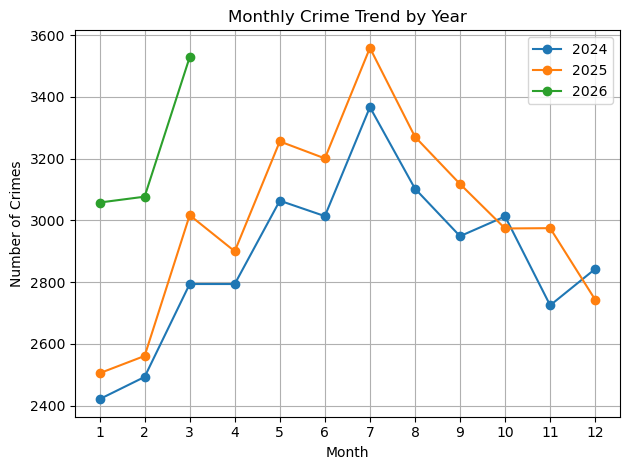

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime
df['reporteddate'] = pd.to_datetime(df['reporteddate'], errors='coerce')

# Create year and month columns
df['year'] = df['reporteddate'].dt.year
df['month'] = df['reporteddate'].dt.month

# Group data
crimes_per_month = df.groupby(['year', 'month']).size().reset_index(name='count')

# Plot
plt.figure()

for year in crimes_per_month['year'].unique():
    subset = crimes_per_month[crimes_per_month['year'] == year]
    plt.plot(subset['month'], subset['count'], marker='o', label=str(year))

plt.title('Monthly Crime Trend by Year')
plt.xlabel('Month')
plt.ylabel('Number of Crimes')
plt.legend()

plt.xticks(range(1, 13))
plt.grid(True)

plt.tight_layout()
plt.show()

/scratch/slurm-36091/ipykernel_73133/2017481576.py:5: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Monthly_Crime_Activity.csv")


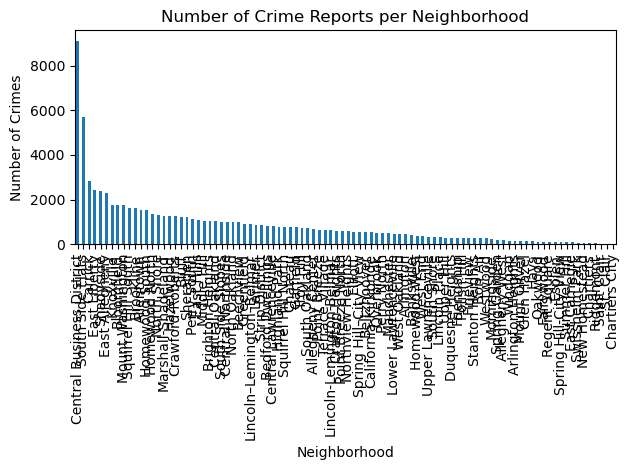

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Monthly_Crime_Activity.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Drop missing neighborhood values
df = df.dropna(subset=['neighborhood'])

# Count crimes per neighborhood
crime_counts = df['neighborhood'].value_counts()

# Plot
plt.figure()
crime_counts.plot(kind='bar')

plt.title('Number of Crime Reports per Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Number of Crimes')

# Rotate labels so they don't overlap
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

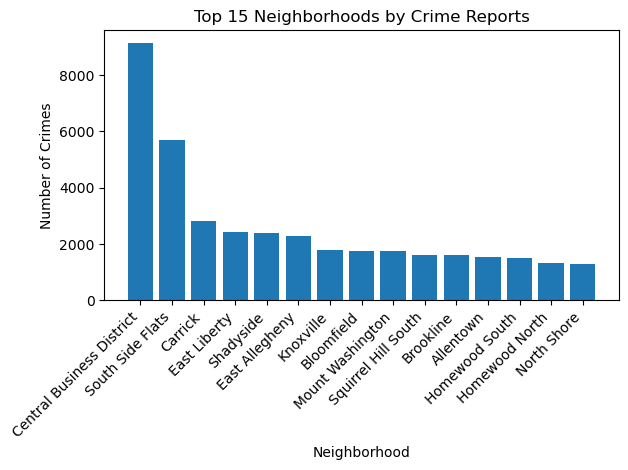

In [32]:
import matplotlib.pyplot as plt

top_neighborhoods = df['neighborhood'].value_counts().head(15)

plt.figure()

# Create positions for bars
x_pos = range(len(top_neighborhoods))

# Plot bars manually
plt.bar(x_pos, top_neighborhoods.values)

# Set labels exactly under bars
plt.xticks(x_pos, top_neighborhoods.index, rotation=45, ha='right')

plt.title('Top 15 Neighborhoods by Crime Reports')
plt.xlabel('Neighborhood')
plt.ylabel('Number of Crimes')

plt.tight_layout()
plt.show()

In [34]:
# Standardize neighborhood names
df['neighborhood'] = df['neighborhood'].str.strip().str.lower()

# Replace variations with a single name
df['neighborhood'] = df['neighborhood'].replace({
    'st. clair': 'saint clair',
    'st clair': 'saint clair'
})

df['neighborhood'] = df['neighborhood'].replace({
    'chartiers': 'chartiers city',
    'chartiers': 'chartiers city'
})


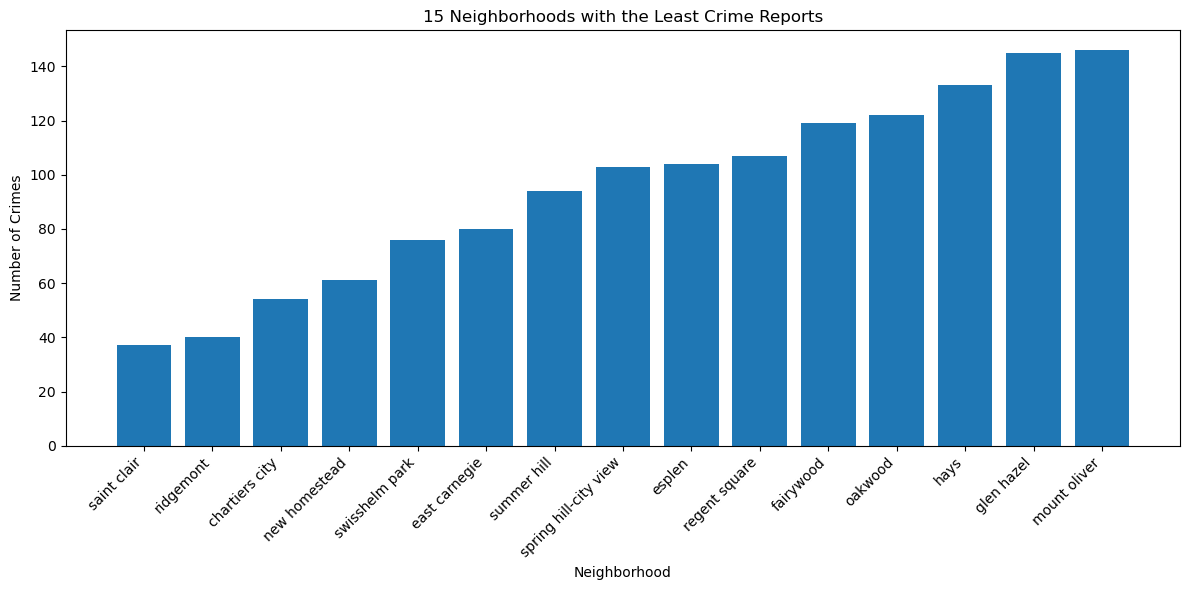

In [35]:
top_neighborhoods = df['neighborhood'].value_counts().tail(15)

# Sort ascending (smallest first)
top_neighborhoods = top_neighborhoods.sort_values()

plt.figure(figsize=(12,6))

x_pos = range(len(top_neighborhoods))

plt.bar(x_pos, top_neighborhoods.values)

plt.xticks(x_pos, top_neighborhoods.index, rotation=45, ha='right')

plt.title('15 Neighborhoods with the Least Crime Reports')
plt.xlabel('Neighborhood')
plt.ylabel('Number of Crimes')

plt.tight_layout()
plt.show()

/scratch/slurm-36091/ipykernel_73133/691359965.py:5: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Monthly_Crime_Activity.csv")


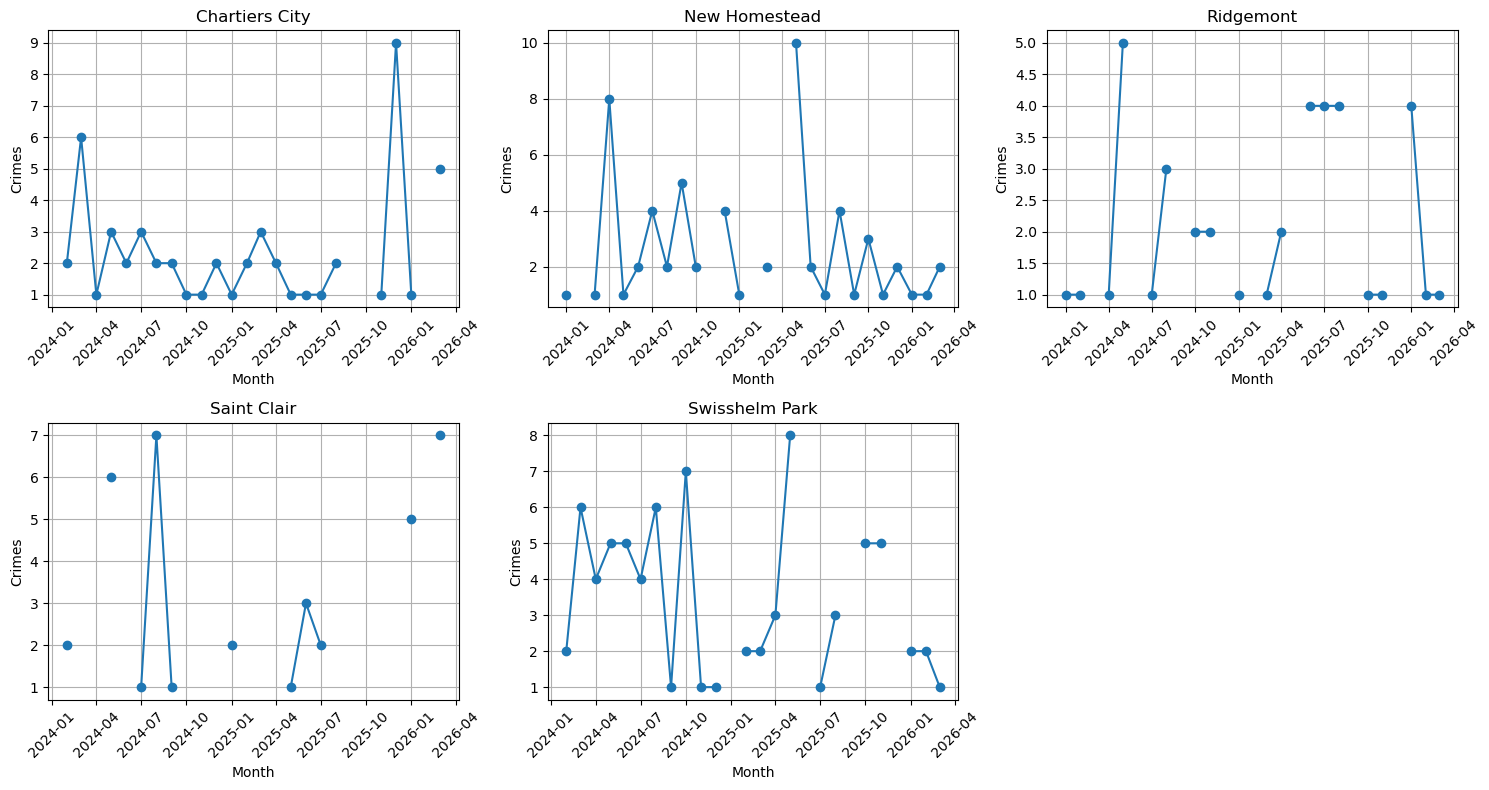

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Monthly_Crime_Activity.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Convert date
df['reporteddate'] = pd.to_datetime(df['reporteddate'], errors='coerce')

# Drop missing values
df = df.dropna(subset=['reporteddate', 'neighborhood'])

# STANDARDIZE neighborhood names
df['neighborhood'] = df['neighborhood'].str.strip().str.lower()

# Merge known duplicates
df['neighborhood'] = df['neighborhood'].replace({
    'st. clair': 'saint clair',
    'st clair': 'saint clair',
    'mt. washington': 'mount washington',
    'mt washington': 'mount washington',
    'chartiers': 'chartiers city',
    'chartiers': 'chartiers city'
})

# Get 5 safest neighborhoods
crime_counts = df['neighborhood'].value_counts()
safest = crime_counts.sort_values().head(5).index

df_safe = df[df['neighborhood'].isin(safest)].copy()

# Create monthly trend
df_safe['year_month'] = df_safe['reporteddate'].dt.to_period('M')

trend = df_safe.groupby(['year_month', 'neighborhood']).size().unstack()
trend.index = trend.index.to_timestamp()

# Make names look nice in plots
trend.columns = trend.columns.str.title()


# Plot in 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, neighborhood in enumerate(trend.columns):
    axes[i].plot(trend.index, trend[neighborhood], marker='o')
    
    axes[i].set_title(neighborhood)
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('Crimes')
    
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True)

# Hide unused subplot
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()